<a href="https://colab.research.google.com/github/Auta01/Pytorch/blob/main/Tabularclassfication%20projects3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install opendatasets --quiet
import opendatasets as od
od.download('https://www.kaggle.com/datasets/mssmartypants/rice-type-classification')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Auta01
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mssmartypants/rice-type-classification


100%|██████████| 888k/888k [00:00<00:00, 840MB/s]

In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
data_df = pd.read_csv('/content/rice-type-classification/riceClassification.csv')

In [4]:
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [5]:
data_df.dropna(inplace=True)
data_df.drop(columns=['id'], inplace=True)

In [6]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [7]:
print(data_df['Class'].unique())

[1 0]


In [8]:
print(data_df['Class'].value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [9]:
original_df = data_df.copy()

for column in data_df.columns:
  data_df[column] =data_df[column]/data_df[column].abs().max()
  data_df.head()

In [10]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [11]:
x = np.array(data_df.iloc[:, :-1])
y = np.array(data_df.iloc[:, -1])

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3)

x_test, x_val, y_test, y_val = train_test_split(x_test, y_test, test_size=0.5 )

In [13]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(12729, 10)
(2728, 10)
(2728, 10)


In [14]:
import torch
from torch.utils.data import Dataset # Ensure Dataset is imported as the base class

class CustomDataset(Dataset):
  def __init__(self, x, y):
    self.x = torch.tensor(x, dtype=torch.float32)
    self.y = torch.tensor(y, dtype=torch.float32)

  def __len__(self):
    return len(self.x)

  def __getitem__(self, index):
    return self.x[index], self.y[index]

In [15]:
# This cell is now empty as its content has been merged into sjb6pYdRqzBM and corrected.

In [16]:
training_data = CustomDataset(x_train, y_train)
validation_data = CustomDataset(x_val, y_val)
test_data = CustomDataset(x_test, y_test)

In [17]:
train_dataloader = DataLoader(training_data, batch_size=8, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=8, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=8, shuffle=True)

In [18]:
#Setting up a diagnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [19]:
#Building our model
HIDDEN_NEURONS = 10
class Mymodel(nn.Module):
  def __init__(self):
    super(Mymodel, self).__init__()
    # Corrected linear layers and their names
    self.fc1 = nn.Linear(x.shape[1], HIDDEN_NEURONS)
    self.fc2 = nn.Linear(HIDDEN_NEURONS, 1) # Output layer for binary classification
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    # Corrected layer usage and added an activation function
    x = self.fc1(x)
    x = torch.relu(x) # Commonly use ReLU activation between hidden layers
    x = self.fc2(x)
    x = self.sigmoid(x)
    return x

model = Mymodel().to(device)

In [20]:
# First, ensure torchsummary is installed (if not already)
!pip install torchsummary --quiet

from torchsummary import summary

# Correct usage of summary: model and input_size tuple
summary(model, input_size=(x.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [21]:
CRITERION = nn.BCELoss()
OPTIMIZER = Adam(model.parameters(), lr=1e-1)

In [22]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_val_plot = []

epochs = 10

for epoch in range(epochs):
  total_acc_train = 0
  total_loss_train = 0
  total_acc_val= 0
  total_loss_val = 0

  # Training loop
  model.train() # Set model to training mode
  for data in train_dataloader:
    inputs, labels = data
    # Move inputs and labels to the correct device
    inputs = inputs.to(device)
    labels = labels.to(device)

    prediction = model(inputs).squeeze(1)

    batch_loss = CRITERION(prediction, labels)
    total_loss_train += batch_loss.item()

    # Correct calculation of training accuracy
    total_acc_train += (prediction.round() == labels).float().sum().item()

    batch_loss.backward()
    OPTIMIZER.step()
    OPTIMIZER.zero_grad()

  # Validation loop (moved outside the training batch loop to run once per epoch)
  model.eval() # Set model to evaluation mode
  with torch.no_grad():
    for data in validation_dataloader:
      inputs, labels = data
      # Move inputs and labels to the correct device
      inputs = inputs.to(device)
      labels = labels.to(device)

      prediction = model(inputs).squeeze(1)
      batch_loss = CRITERION(prediction, labels)
      total_loss_val += batch_loss.item() # Corrected: Use += for accumulation

      # Correct calculation of validation accuracy
      total_acc_val += (prediction.round() == labels).float().sum().item()

  # Calculate average loss and accuracy for the epoch
  avg_train_loss = total_loss_train / len(train_dataloader)
  avg_train_acc = total_acc_train / len(training_data)
  avg_val_loss = total_loss_val / len(validation_dataloader)
  avg_val_acc = total_acc_val / len(validation_data)

  total_loss_train_plot.append(avg_train_loss)
  total_loss_val_plot.append(avg_val_loss)
  total_acc_train_plot.append(avg_train_acc * 100)
  total_acc_val_plot.append(avg_val_acc * 100)

  print(f'Epoch {epoch+1}/{epochs} - ' +
        f'Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc*100:.2f}% | ' +
        f'Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc*100:.2f}%')

Epoch 1/10 - Train Loss: 0.0944, Train Acc: 96.71% | Val Loss: 0.0412, Val Acc: 98.64%
Epoch 2/10 - Train Loss: 0.0593, Train Acc: 98.04% | Val Loss: 0.0400, Val Acc: 98.64%
Epoch 3/10 - Train Loss: 0.0566, Train Acc: 98.09% | Val Loss: 0.0524, Val Acc: 98.06%
Epoch 4/10 - Train Loss: 0.0584, Train Acc: 98.02% | Val Loss: 0.0415, Val Acc: 98.57%
Epoch 5/10 - Train Loss: 0.0561, Train Acc: 98.11% | Val Loss: 0.0773, Val Acc: 97.21%
Epoch 6/10 - Train Loss: 0.0558, Train Acc: 98.08% | Val Loss: 0.0406, Val Acc: 98.61%
Epoch 7/10 - Train Loss: 0.0568, Train Acc: 98.18% | Val Loss: 0.0417, Val Acc: 98.53%
Epoch 8/10 - Train Loss: 0.0534, Train Acc: 98.25% | Val Loss: 0.0478, Val Acc: 98.39%
Epoch 9/10 - Train Loss: 0.0549, Train Acc: 98.21% | Val Loss: 0.0762, Val Acc: 97.54%
Epoch 10/10 - Train Loss: 0.0516, Train Acc: 98.35% | Val Loss: 0.0417, Val Acc: 98.68%


In [23]:
model.eval() # Set model to evaluation mode
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for inputs, labels in test_dataloader:
    # Move inputs and labels to the correct device
    inputs = inputs.to(device)
    labels = labels.to(device)

    prediction = model(inputs).squeeze(1)
    batch_loss = CRITERION(prediction, labels)
    total_loss_test += batch_loss.item()

    # Correct calculation of test accuracy
    total_acc_test += (prediction.round() == labels).float().sum().item()

  # Calculate average loss and accuracy for the test set
  avg_test_loss = total_loss_test / len(test_dataloader)
  avg_test_acc = total_acc_test / len(test_data)

  print(f'Test Loss: {avg_test_loss:.4f}, Test Accuracy: {avg_test_acc*100:.2f}%')

Test Loss: 0.0424, Test Accuracy: 98.86%


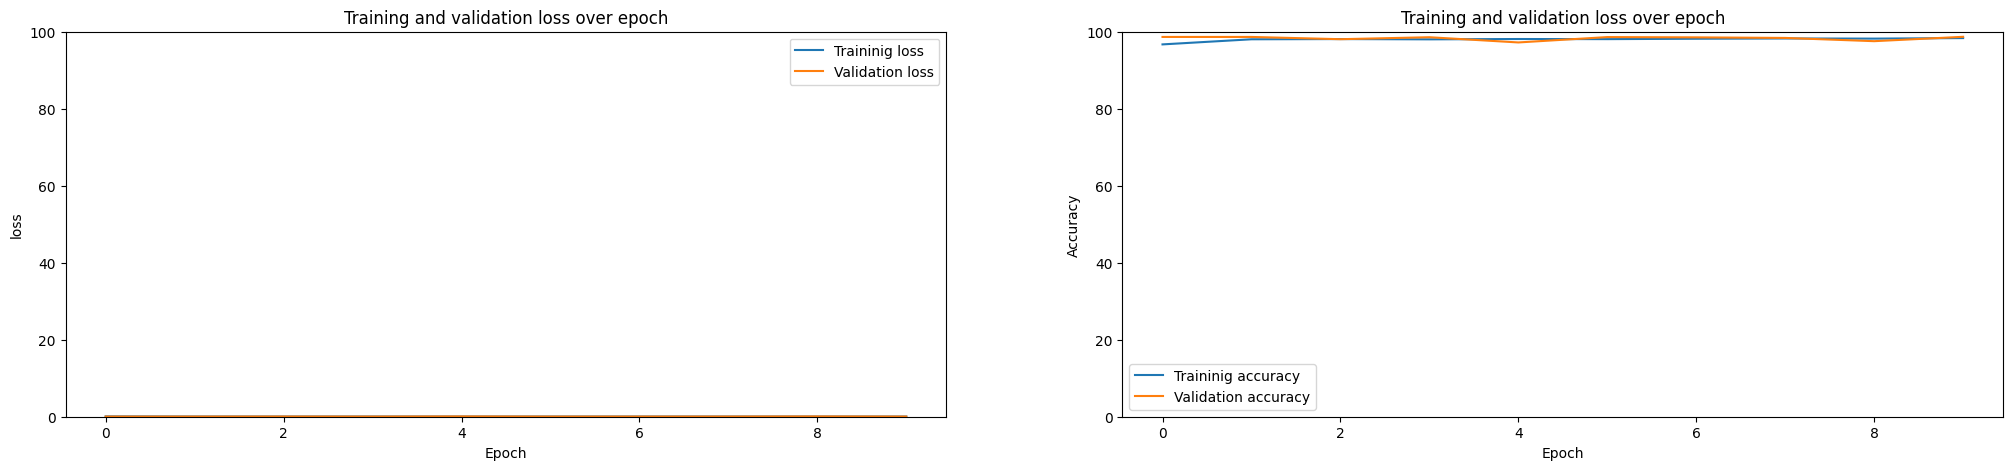

In [24]:
fig, axs, = plt.subplots(nrows=1 , ncols=2, figsize=(25,5))
axs[0].plot(total_loss_train_plot, label = 'Traininig loss')
axs[0].plot(total_loss_val_plot, label = 'Validation loss')
axs[0].set_title('Training and validation loss over epoch')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('loss')
axs[0].set_ylim([0, 100])
axs[0].legend()


axs[1].plot(total_acc_train_plot, label = 'Traininig accuracy')
axs[1].plot(total_acc_val_plot, label = 'Validation accuracy')
axs[1].set_title('Training and validation loss over epoch')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0,100])
axs[1].legend()

plt.show()

In [36]:
area = 599 / original_df['Area'].abs().max()
MajorAxisLength = 599 / original_df['MajorAxisLength'].abs().max()
MinorAxisLength = 599 / original_df['MinorAxisLength'].abs().max()
Eccentricity = 599 / original_df['Eccentricity'].abs().max()
ConvexArea = 599 / original_df['ConvexArea'].abs().max()
EquivDiameter = 599 / original_df['EquivDiameter'].abs().max()
Extent = 599 / original_df['Extent'].abs().max()
Perimeter = 599 / original_df['Perimeter'].abs().max()
Roundness = 599 / original_df['Roundness'].abs().max()
AspectRation = 599 / original_df['AspectRation'].abs().max()

# Create a list of the normalized values
input_values = [
    area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea,
    EquivDiameter, Extent, Perimeter, Roundness, AspectRation
]

# Convert the list to a torch tensor and ensure it has the correct shape and dtype
# The .to(device) moves the tensor to the appropriate device (CPU/GPU)
input_tensor = torch.tensor([input_values], dtype=torch.float32).to(device)

# Make the prediction
model.eval() # Set model to evaluation mode
with torch.no_grad():
  my_prediction = model(input_tensor).item() # Use .item() to get scalar from 0-dim tensor

predicted_class = round(my_prediction)
print(f"The predicted probability is: {my_prediction:.4f}")
print(f"The predicted class is: {predicted_class}")

The predicted probability is: 1.0000
The predicted class is: 1
